# Forecasting Model Comparison â€” Final Results

Compares 5 forecasting models on **development OOF (2020â€“2024)** and the **untouched 2025 holdout**.

| # | Model | Description |
|---|-------|-------------|
| 1 | `elo` | p = p_elo â€” no fitting |
| 2 | `logreg_no_elo` | Logistic regression on X only |
| 3 | `xgb_no_elo` | XGBoost on X only (no base_margin) |
| 4 | `logreg_with_elo` | Logistic regression on X with logit(p_elo) as feature |
| 5 | `xgb_with_elo` | XGBoost on X with base_margin = logit(p_elo) |

All hyperparameters and features are **frozen**. This is a reporting notebook, not a tuning notebook.

## Section 1 â€” Setup

In [24]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
%matplotlib inline

PROJECT_ROOT = Path("../..").resolve()
GOLD_DIR     = PROJECT_ROOT / "data" / "gold"
OUT_DIR      = PROJECT_ROOT / "data" / "model_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Gold dir:     {GOLD_DIR}")

Project root: C:\Users\arius\Desktop\kalshi_wnba_bot\organized
Gold dir:     C:\Users\arius\Desktop\kalshi_wnba_bot\organized\data\gold


In [25]:
# --- Frozen XGBoost hyperparameters (from XGB_tuning3, stability-chosen) ---
# ══════════════════════════════════════════════════════════════════════
# FINAL LOCKED HYPERPARAMETERS (single source of truth)
# ──────────────────────────────────────────────────────────────────────
# Elo:      H=25, K=20, alpha=0.45, beta=1.0, mu=1505
# Features: N_players=7, h_M=7, L_inj=14, tau=150, h_team=7
# XGBoost (Stage 3, rank 2 — stability-chosen):
#   max_depth=6, min_child_weight=3, gamma=0.1, colsample_bytree=0.6,
#   subsample=0.8, reg_lambda=1.0, reg_alpha=0.0, learning_rate=0.02
#   NUM_BOOST_ROUND=3000, EARLY_STOPPING_ROUNDS=150
# ══════════════════════════════════════════════════════════════════════

XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "logloss",
    "max_depth":        6,
    "min_child_weight": 3,
    "subsample":        0.8,
    "colsample_bytree": 0.6,
    "reg_lambda":       1.0,
    "reg_alpha":        0.0,
    "gamma":            0.1,
    "learning_rate":    0.02,
    "seed":             42,
    "nthread":         -1,
}
NUM_BOOST_ROUND       = 3000
EARLY_STOPPING_ROUNDS = 150
N_PLAYERS             = 7

CLIP_EPS    = 1e-6
OOF_YEARS   = list(range(2020, 2025))
TRAIN_START = 2015

MODEL_ORDER = ["elo", "logreg_no_elo", "xgb_no_elo", "logreg_with_elo", "xgb_with_elo"]

MODEL_LABELS = {
    "elo":             "Elo Only",
    "logreg_no_elo":   "LogReg (no Elo)",
    "xgb_no_elo":      "XGBoost (no Elo)",
    "logreg_with_elo": "LogReg (+ Elo)",
    "xgb_with_elo":    "XGBoost (+ Elo)",
}

COLORS = {
    "elo":             "#7f8c8d",
    "logreg_no_elo":   "#e67e22",
    "xgb_no_elo":      "#e74c3c",
    "logreg_with_elo": "#2ecc71",
    "xgb_with_elo":    "#3498db",
}

In [26]:
# --- Feature column definitions (same as 32_run_xgboost_cv.py) ---
PLAYER_MODEL_FEATURES = [
    "m_ewma_pre", "q_pre", "days_since_first_report_pre",
    "days_since_last_dnp_pre", "consec_dnps_pre", "played_last_game_pre",
    "minutes_last_game_pre", "days_since_last_played_pre",
    "injury_present_flag_pre",
]
RECENT_FORM_FEATURES = [
    "net_rtg_ewma_pre", "efg_ewma_pre", "tov_pct_ewma_pre",
    "orb_pct_ewma_pre", "ftr_ewma_pre",
]
STYLE_FEATURES = [
    "off_3pa_rate_pre", "def_3pa_allowed_pre", "off_2pa_rate_pre",
    "def_2pa_allowed_pre", "off_tov_pct_pre", "def_forced_tov_pre",
]
SCHEDULE_FEATURES = [
    "days_rest_pre", "is_b2b_pre", "games_last_4_days_pre",
    "games_last_7_days_pre", "travel_miles_pre", "timezone_shift_hours_pre",
]

def build_feature_cols(n_players: int) -> list[str]:
    cols = []
    for side in ("home", "away"):
        for slot in range(1, n_players + 1):
            for feat in PLAYER_MODEL_FEATURES:
                cols.append(f"{side}_p{slot}_{feat}")
    for feat in RECENT_FORM_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    for feat in STYLE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    for feat in SCHEDULE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    return cols

FEATURE_COLS = build_feature_cols(N_PLAYERS)
print(f"Ordinary feature columns: {len(FEATURE_COLS)}")

Ordinary feature columns: 160


In [27]:
# --- Data loaders ---
def load_gold(season: int) -> pd.DataFrame:
    p = GOLD_DIR / f"game_xgboost_input_{season}_REGPST.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    df = pd.read_csv(p)
    df["season"] = df["season"].astype(int)
    cold = (df["home_p1_m_ewma_pre"] == 0) | (df["away_p1_m_ewma_pre"] == 0)
    n_drop = cold.sum()
    if n_drop:
        df = df[~cold].reset_index(drop=True)
        print(f"  [load {season}] dropped {n_drop} cold-start rows")
    return df

def load_range(start: int, end: int) -> pd.DataFrame:
    dfs = []
    for y in range(start, end + 1):
        try:
            dfs.append(load_gold(y))
        except FileNotFoundError as e:
            print(f"  WARNING: {e}")
    return pd.concat(dfs, ignore_index=True).dropna(subset=["home_win", "base_margin"])

## Section 2 â€” Helper Functions

In [28]:
# 2.1 Metrics / 2.2 Clipping / 2.3 Logit

def clip(p):
    return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def logit(p):
    p = clip(p)
    return np.log(p / (1 - p))

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def metrics(y, p):
    p = clip(p)
    return {
        "log_loss":  log_loss(y, p),
        "brier":     brier_score_loss(y, p),
        "accuracy":  accuracy_score(y, (p >= 0.5).astype(int)),
        "n_games":   len(y),
    }

In [29]:
# 2.4 Fit/predict wrappers

def fit_predict_logreg_no_elo(X_train, y_train, X_test):
    """Logistic regression on features only (no Elo)."""
    lr = LogisticRegression(max_iter=2000, solver="lbfgs", penalty="l2", C=1.0, random_state=42)
    lr.fit(X_train, y_train)
    return lr.predict_proba(X_test)[:, 1]


def fit_predict_logreg_with_elo(X_train, y_train, bm_train, X_test, bm_test):
    """Logistic regression with logit(p_elo) included as a feature.
    Learns: logit(p) = a + b0*logit(p_elo) + b'x
    """
    X_tr = np.column_stack([bm_train, X_train])
    X_te = np.column_stack([bm_test, X_test])
    lr = LogisticRegression(max_iter=2000, solver="lbfgs", penalty="l2", C=1.0, random_state=42)
    lr.fit(X_tr, y_train)
    return lr.predict_proba(X_te)[:, 1]


def fit_predict_xgb(X_train, y_train, X_es_val, y_es_val,
                     X_test, bm_train=None, bm_es_val=None, bm_test=None,
                     feature_names=None):
    """XGBoost with optional base_margin. Nested early stopping:
    find best_round on es_val, retrain on train+es_val for best_round, predict test.
    """
    def make_dm(X, y, bm):
        kw = dict(data=X.astype(float), label=y.astype(float),
                  feature_names=feature_names, missing=np.nan)
        if bm is not None:
            kw["base_margin"] = bm.astype(float)
        return xgb.DMatrix(**kw)

    dm_es_train = make_dm(X_train, y_train, bm_train)
    dm_es_val   = make_dm(X_es_val, y_es_val, bm_es_val)

    es_model = xgb.train(
        XGB_PARAMS, dm_es_train,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(dm_es_val, "val")],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )
    best_round = es_model.best_iteration + 1

    # Retrain on train + es_val
    X_full  = np.vstack([X_train, X_es_val])
    y_full  = np.concatenate([y_train, y_es_val])
    bm_full = np.concatenate([bm_train, bm_es_val]) if bm_train is not None else None
    dm_full = make_dm(X_full, y_full, bm_full)
    dm_test = make_dm(X_test, np.zeros(len(X_test)), bm_test)

    model = xgb.train(XGB_PARAMS, dm_full, num_boost_round=best_round, verbose_eval=False)
    preds = model.predict(dm_test)
    return clip(preds), best_round, model

## Section 3 â€” Walk-Forward Comparison on OOF 2020â€“2024

For each test year Y:
- **ES-train** on 2015..Y-2, **ES-val** on Y-1 to find best_round (XGBoost only)
- **Retrain** on 2015..Y-1 for best_round trees
- **Predict** on Y

In [30]:
all_oof = []

for test_year in OOF_YEARS:
    print(f"\n--- Fold: test_year = {test_year} ---")
    es_val_year = test_year - 1

    es_train_df = load_range(TRAIN_START, es_val_year - 1)
    es_val_df   = load_gold(es_val_year).dropna(subset=["home_win", "base_margin"])
    test_df     = load_gold(test_year).dropna(subset=["home_win", "base_margin"])

    avail = [c for c in FEATURE_COLS if c in es_train_df.columns]

    X_es_train  = es_train_df[avail].values
    X_es_val    = es_val_df[avail].values
    X_test      = test_df[avail].values
    y_es_train  = es_train_df["home_win"].values.astype(float)
    y_es_val    = es_val_df["home_win"].values.astype(float)
    y_test      = test_df["home_win"].values.astype(float)
    bm_es_train = es_train_df["base_margin"].values.astype(float)
    bm_es_val   = es_val_df["base_margin"].values.astype(float)
    bm_test     = test_df["base_margin"].values.astype(float)
    p_elo_test  = clip(test_df["p_elo"].values.astype(float))

    # Full train for logreg (no early stopping needed)
    X_lr_train  = np.vstack([X_es_train, X_es_val])
    y_lr_train  = np.concatenate([y_es_train, y_es_val])
    bm_lr_train = np.concatenate([bm_es_train, bm_es_val])

    fold_preds = {}

    # 1. Elo-only
    fold_preds["elo"] = p_elo_test

    # 2. Logistic regression without Elo
    fold_preds["logreg_no_elo"] = fit_predict_logreg_no_elo(X_lr_train, y_lr_train, X_test)

    # 3. XGBoost without Elo
    p3, br3, _ = fit_predict_xgb(X_es_train, y_es_train, X_es_val, y_es_val, X_test, feature_names=avail)
    fold_preds["xgb_no_elo"] = p3
    print(f"  xgb_no_elo best_round={br3}")

    # 4. Logistic regression with Elo
    fold_preds["logreg_with_elo"] = fit_predict_logreg_with_elo(X_lr_train, y_lr_train, bm_lr_train, X_test, bm_test)

    # 5. XGBoost with Elo
    p5, br5, _ = fit_predict_xgb(X_es_train, y_es_train, X_es_val, y_es_val, X_test,
                                   bm_train=bm_es_train, bm_es_val=bm_es_val, bm_test=bm_test,
                                   feature_names=avail)
    fold_preds["xgb_with_elo"] = p5
    print(f"  xgb_with_elo best_round={br5}")

    # Collect per-game predictions
    for model_name, preds in fold_preds.items():
        for i in range(len(test_df)):
            all_oof.append({
                "game_id":   test_df.iloc[i]["game_id"],
                "season":    int(test_df.iloc[i]["season"]),
                "home_win":  int(y_test[i]),
                "model":     model_name,
                "pred_prob": float(preds[i]),
            })

    # Print fold metrics
    for name, preds in fold_preds.items():
        m = metrics(y_test, preds)
        print(f"  {name:25s}  LL={m['log_loss']:.5f}  Brier={m['brier']:.5f}  Acc={m['accuracy']:.3f}")

oof_df = pd.DataFrame(all_oof)
oof_df.to_csv(OUT_DIR / "oof_model_comparison_2020_2024.csv", index=False)
print(f"\nSaved: oof_model_comparison_2020_2024.csv  ({len(oof_df)} rows)")


--- Fold: test_year = 2020 ---
  [load 2015] dropped 7 cold-start rows
  xgb_no_elo best_round=211
  xgb_with_elo best_round=10
  elo                        LL=0.59431  Brier=0.20221  Acc=0.721
  logreg_no_elo              LL=1.16271  Brier=0.27637  Acc=0.653
  xgb_no_elo                 LL=0.62133  Brier=0.21632  Acc=0.639
  logreg_with_elo            LL=1.05880  Brier=0.27231  Acc=0.646
  xgb_with_elo               LL=0.59524  Brier=0.20263  Acc=0.721

--- Fold: test_year = 2021 ---
  [load 2015] dropped 7 cold-start rows
  xgb_no_elo best_round=238
  xgb_with_elo best_round=63
  elo                        LL=0.60669  Brier=0.21111  Acc=0.646
  logreg_no_elo              LL=0.70202  Brier=0.23002  Acc=0.636
  xgb_no_elo                 LL=0.63208  Brier=0.22169  Acc=0.598
  logreg_with_elo            LL=0.66943  Brier=0.22555  Acc=0.641
  xgb_with_elo               LL=0.60520  Brier=0.21045  Acc=0.665

--- Fold: test_year = 2022 ---
  [load 2015] dropped 7 cold-start rows
  xgb_no_e

### Table 1 â€” Development-period model comparison (OOF 2020â€“2024 pooled)

In [31]:
rows = []
for model_name in MODEL_ORDER:
    sub = oof_df[oof_df["model"] == model_name]
    m = metrics(sub["home_win"].values, sub["pred_prob"].values)
    m["model"] = model_name
    rows.append(m)

dev_summary = pd.DataFrame(rows)[["model", "log_loss", "brier", "accuracy", "n_games"]]
dev_summary.to_csv(OUT_DIR / "development_summary_table.csv", index=False)
dev_summary

,model,log_loss,brier,accuracy,n_games
0,elo,0.602163,0.207240,0.677708,1117
1,logreg_no_elo,0.785486,0.236073,0.643688,1117
2,xgb_no_elo,0.622805,0.216548,0.650850,1117
3,logreg_with_elo,0.732191,0.228492,0.658908,1117
4,xgb_with_elo,0.599394,0.205496,0.694718,1117


### Table 2 â€” Per-fold development-period comparison

In [32]:
fold_rows = []
for test_year in OOF_YEARS:
    for model_name in MODEL_ORDER:
        sub = oof_df[(oof_df["model"] == model_name) & (oof_df["season"] == test_year)]
        if len(sub) == 0:
            continue
        m = metrics(sub["home_win"].values, sub["pred_prob"].values)
        m["fold_year"] = test_year
        m["model"] = model_name
        fold_rows.append(m)

fold_table = pd.DataFrame(fold_rows)[["fold_year", "model", "log_loss", "brier", "accuracy", "n_games"]]
fold_table.to_csv(OUT_DIR / "development_by_fold_table.csv", index=False)
fold_table

,fold_year,model,log_loss,brier,accuracy,n_games
0,2020,elo,0.594308,0.202210,0.721088,147
1,2020,logreg_no_elo,1.162709,0.276372,0.653061,147
2,2020,xgb_no_elo,0.621327,0.216319,0.639456,147
3,2020,logreg_with_elo,1.058797,0.272305,0.646259,147
4,2020,xgb_with_elo,0.595243,0.202632,0.721088,147
5,2021,elo,0.606694,0.211113,0.645933,209
6,2021,logreg_no_elo,0.702022,0.230019,0.636364,209
7,2021,xgb_no_elo,0.632079,0.221694,0.598086,209
8,2021,logreg_with_elo,0.669425,0.225549,0.641148,209
9,2021,xgb_with_elo,0.605204,0.210446,0.665072,209


## Section 4 â€” Final 2025 Holdout Comparison

Train each model on **all 2015â€“2024**, predict on **2025**.

In [33]:
# Load full training data and holdout
full_train_df = load_range(TRAIN_START, 2024)
holdout_df    = load_gold(2025).dropna(subset=["home_win", "base_margin"])

avail = [c for c in FEATURE_COLS if c in full_train_df.columns]

X_full_train  = full_train_df[avail].values
y_full_train  = full_train_df["home_win"].values.astype(float)
bm_full_train = full_train_df["base_margin"].values.astype(float)

X_holdout     = holdout_df[avail].values
y_holdout     = holdout_df["home_win"].values.astype(float)
bm_holdout    = holdout_df["base_margin"].values.astype(float)
p_elo_holdout = clip(holdout_df["p_elo"].values.astype(float))

# For XGBoost: ES-train on 2015-2023, ES-val on 2024
es_train_h_df = load_range(TRAIN_START, 2023)
es_val_h_df   = load_gold(2024).dropna(subset=["home_win", "base_margin"])

X_es_tr_h  = es_train_h_df[avail].values
y_es_tr_h  = es_train_h_df["home_win"].values.astype(float)
bm_es_tr_h = es_train_h_df["base_margin"].values.astype(float)
X_es_val_h = es_val_h_df[avail].values
y_es_val_h = es_val_h_df["home_win"].values.astype(float)
bm_es_val_h = es_val_h_df["base_margin"].values.astype(float)

holdout_preds = {}

# 1. Elo-only
holdout_preds["elo"] = p_elo_holdout

# 2. Logistic regression without Elo
holdout_preds["logreg_no_elo"] = fit_predict_logreg_no_elo(X_full_train, y_full_train, X_holdout)

# 3. XGBoost without Elo
p3, br3, xgb_no_elo_model = fit_predict_xgb(X_es_tr_h, y_es_tr_h, X_es_val_h, y_es_val_h, X_holdout, feature_names=avail)
holdout_preds["xgb_no_elo"] = p3
print(f"xgb_no_elo holdout best_round={br3}")

# 4. Logistic regression with Elo
holdout_preds["logreg_with_elo"] = fit_predict_logreg_with_elo(
    X_full_train, y_full_train, bm_full_train, X_holdout, bm_holdout)

# 5. XGBoost with Elo
p5, br5, xgb_elo_model = fit_predict_xgb(X_es_tr_h, y_es_tr_h, X_es_val_h, y_es_val_h, X_holdout,
                               bm_train=bm_es_tr_h, bm_es_val=bm_es_val_h, bm_test=bm_holdout,
                               feature_names=avail)
holdout_preds["xgb_with_elo"] = p5
print(f"xgb_with_elo holdout best_round={br5}")

# Save per-game predictions
holdout_rows = []
for model_name, preds in holdout_preds.items():
    for i in range(len(holdout_df)):
        holdout_rows.append({
            "game_id":   holdout_df.iloc[i]["game_id"],
            "season":    2025,
            "home_win":  int(y_holdout[i]),
            "model":     model_name,
            "pred_prob": float(preds[i]),
        })
holdout_pred_df = pd.DataFrame(holdout_rows)
holdout_pred_df.to_csv(OUT_DIR / "holdout_model_comparison_2025.csv", index=False)
print(f"Saved: holdout_model_comparison_2025.csv ({len(holdout_pred_df)} rows)")

  [load 2015] dropped 7 cold-start rows
  [load 2015] dropped 7 cold-start rows
xgb_no_elo holdout best_round=325
xgb_with_elo holdout best_round=88
Saved: holdout_model_comparison_2025.csv (1550 rows)


### Table 3 â€” Final 2025 holdout comparison

In [34]:
holdout_rows_summary = []
for model_name in MODEL_ORDER:
    sub = holdout_pred_df[holdout_pred_df["model"] == model_name]
    m = metrics(sub["home_win"].values, sub["pred_prob"].values)
    m["model"] = model_name
    holdout_rows_summary.append(m)

holdout_summary = pd.DataFrame(holdout_rows_summary)[["model", "log_loss", "brier", "accuracy", "n_games"]]
holdout_summary.to_csv(OUT_DIR / "holdout_summary_table.csv", index=False)
holdout_summary

,model,log_loss,brier,accuracy,n_games
0,elo,0.615098,0.213165,0.667742,310
1,logreg_no_elo,0.699122,0.242812,0.641935,310
2,xgb_no_elo,0.632729,0.218845,0.667742,310
3,logreg_with_elo,0.668437,0.233164,0.648387,310
4,xgb_with_elo,0.612148,0.211232,0.674194,310


### Table 4 â€” Improvement relative to Elo

Negative values = better than Elo (for log_loss and brier), positive = better (for accuracy).

In [35]:
elo_dev  = dev_summary[dev_summary["model"] == "elo"].iloc[0]
elo_hold = holdout_summary[holdout_summary["model"] == "elo"].iloc[0]

delta_rows = []
for _, row in dev_summary.iterrows():
    if row["model"] == "elo":
        continue
    d = {"model": row["model"],
         "oof_d_logloss":  round(row["log_loss"] - elo_dev["log_loss"], 5),
         "oof_d_brier":    round(row["brier"] - elo_dev["brier"], 5),
         "oof_d_accuracy": round(row["accuracy"] - elo_dev["accuracy"], 4)}
    h = holdout_summary[holdout_summary["model"] == row["model"]].iloc[0]
    d["holdout_d_logloss"]  = round(h["log_loss"] - elo_hold["log_loss"], 5)
    d["holdout_d_brier"]    = round(h["brier"] - elo_hold["brier"], 5)
    d["holdout_d_accuracy"] = round(h["accuracy"] - elo_hold["accuracy"], 4)
    delta_rows.append(d)

delta_df = pd.DataFrame(delta_rows)
delta_df

,model,oof_d_logloss,oof_d_brier,oof_d_accuracy,holdout_d_logloss,holdout_d_brier,holdout_d_accuracy
0,logreg_no_elo,0.18332,0.02883,-0.0340,0.08402,0.02965,-0.0258
1,xgb_no_elo,0.02064,0.00931,-0.0269,0.01763,0.00568,0.0000
2,logreg_with_elo,0.13003,0.02125,-0.0188,0.05334,0.02000,-0.0194
3,xgb_with_elo,-0.00277,-0.00174,0.0170,-0.00295,-0.00193,0.0065


## Section 5 â€” Graphs

In [36]:
def bar_chart(summary_df, metric, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(MODEL_ORDER))
    vals = [summary_df[summary_df["model"] == m][metric].iloc[0] for m in MODEL_ORDER]
    colors = [COLORS[m] for m in MODEL_ORDER]
    bars = ax.bar(x, vals, color=colors, edgecolor="white", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], fontsize=9)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return fig

### Graph 1 â€” OOF Log Loss by Model

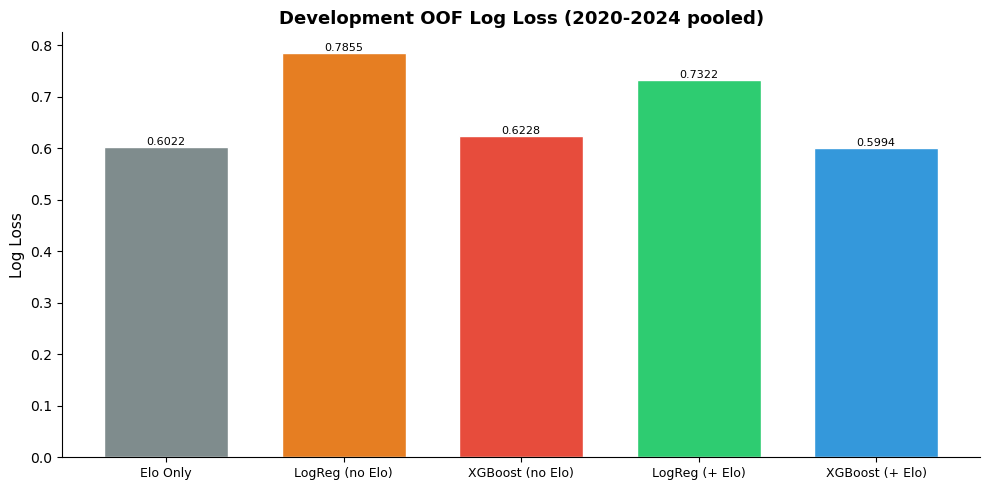

In [37]:
fig = bar_chart(dev_summary, "log_loss", "Development OOF Log Loss (2020-2024 pooled)")
fig.savefig(OUT_DIR / "oof_logloss_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 2 â€” Holdout Log Loss by Model

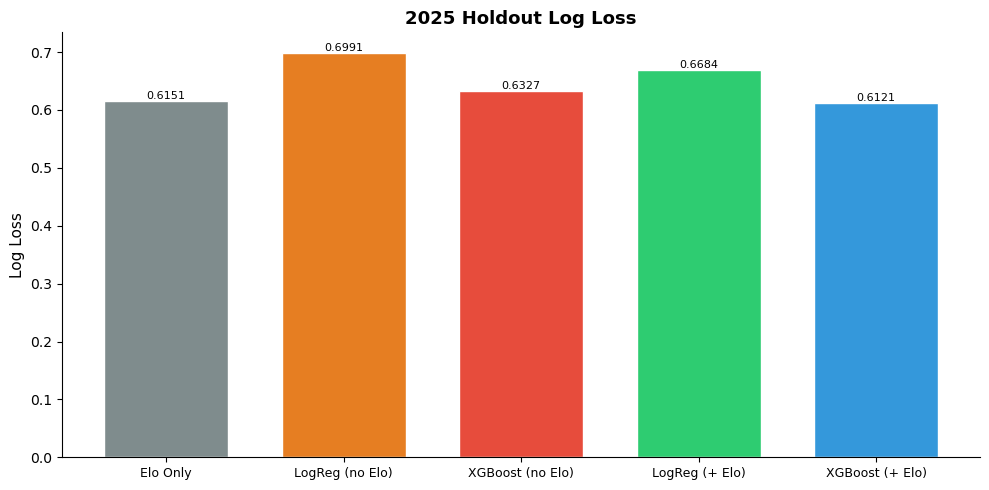

In [38]:
fig = bar_chart(holdout_summary, "log_loss", "2025 Holdout Log Loss")
fig.savefig(OUT_DIR / "holdout_logloss_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 3 â€” Per-Fold Log Loss (2020â€“2024)

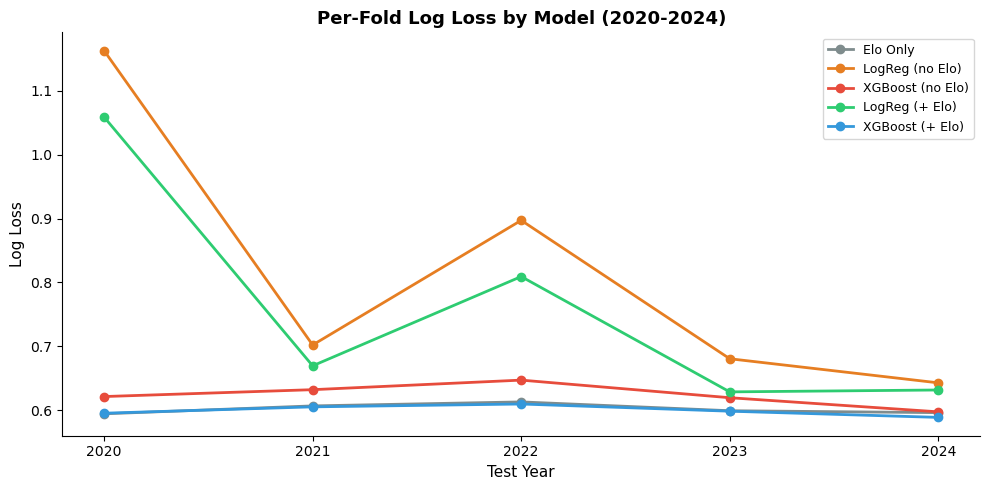

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
for model_name in MODEL_ORDER:
    ll_by_year = []
    for y in OOF_YEARS:
        sub = oof_df[(oof_df["model"] == model_name) & (oof_df["season"] == y)]
        ll_by_year.append(log_loss(sub["home_win"], clip(sub["pred_prob"])))
    ax.plot(OOF_YEARS, ll_by_year, marker="o", label=MODEL_LABELS[model_name],
            color=COLORS[model_name], linewidth=2, markersize=6)

ax.set_xlabel("Test Year", fontsize=11)
ax.set_ylabel("Log Loss", fontsize=11)
ax.set_title("Per-Fold Log Loss by Model (2020-2024)", fontsize=13, fontweight="bold")
ax.set_xticks(OOF_YEARS)
ax.legend(fontsize=9, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "per_fold_logloss.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 4 â€” Reliability / Calibration Curves

Bins predicted probabilities into deciles and plots observed win rate vs predicted probability for key models.

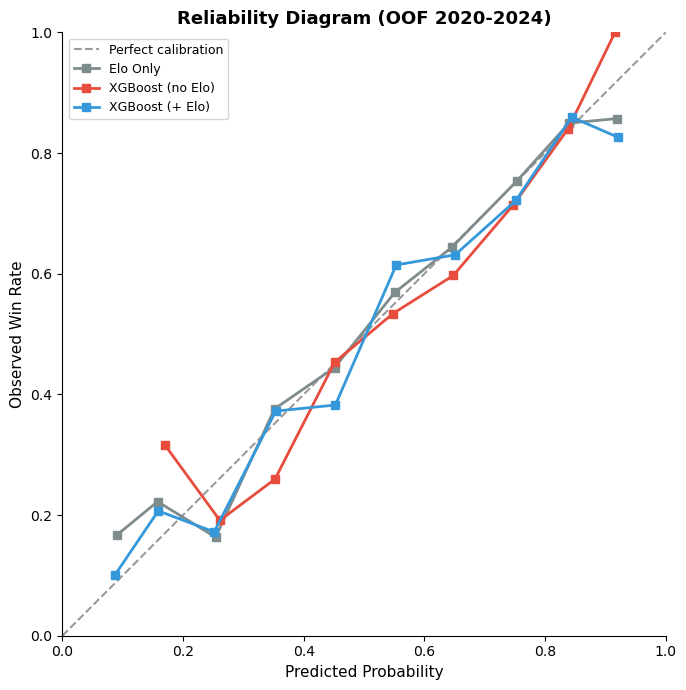

In [40]:
def reliability_curve(y, p, n_bins=10):
    """Return (mean_pred, mean_obs, counts) per bin."""
    bins = np.linspace(0, 1, n_bins + 1)
    mean_pred, mean_obs, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi) if hi < 1 else (p >= lo) & (p <= hi)
        if mask.sum() == 0:
            continue
        mean_pred.append(p[mask].mean())
        mean_obs.append(y[mask].mean())
        counts.append(mask.sum())
    return np.array(mean_pred), np.array(mean_obs), np.array(counts)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")

for model_name in ["elo", "xgb_no_elo", "xgb_with_elo"]:
    sub = oof_df[oof_df["model"] == model_name]
    mp, mo, _ = reliability_curve(sub["home_win"].values, sub["pred_prob"].values, n_bins=10)
    ax.plot(mp, mo, marker="s", label=MODEL_LABELS[model_name],
            color=COLORS[model_name], linewidth=2, markersize=6)

ax.set_xlabel("Predicted Probability", fontsize=11)
ax.set_ylabel("Observed Win Rate", fontsize=11)
ax.set_title("Reliability Diagram (OOF 2020-2024)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / "reliability_curves_oof.png", dpi=150, bbox_inches="tight")
plt.show()

### Graph 5 â€” Brier Score Comparison (OOF + Holdout)

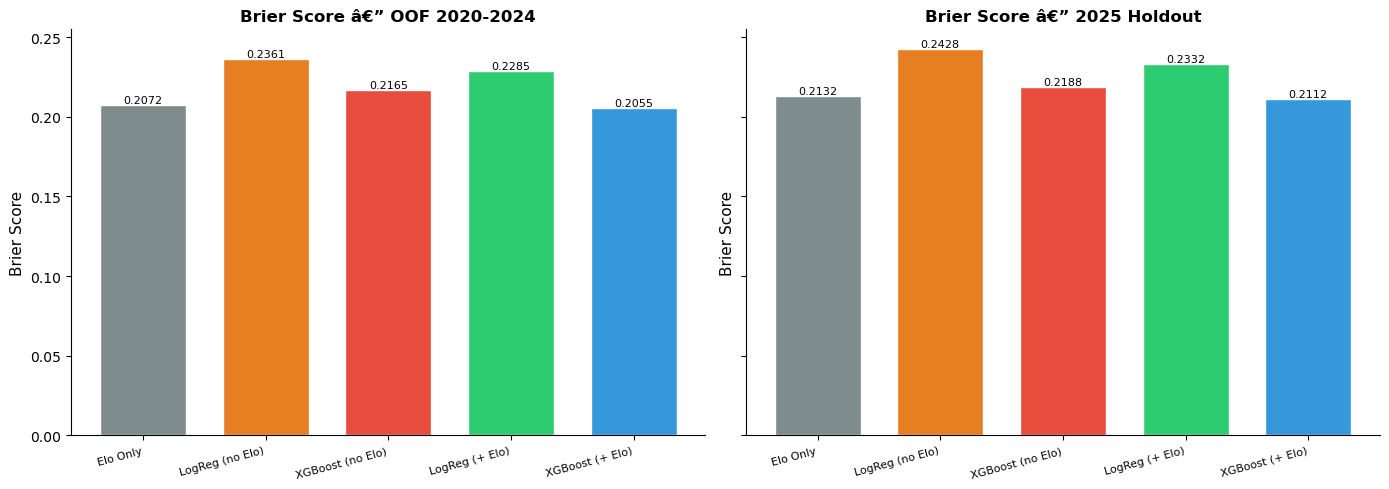

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (summary, title) in zip(axes, [(dev_summary, "OOF 2020-2024"), (holdout_summary, "2025 Holdout")]):
    x = range(len(MODEL_ORDER))
    vals = [summary[summary["model"] == m]["brier"].iloc[0] for m in MODEL_ORDER]
    colors = [COLORS[m] for m in MODEL_ORDER]
    bars = ax.bar(x, vals, color=colors, edgecolor="white", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Brier Score", fontsize=11)
    ax.set_title(f"Brier Score â€” {title}", fontsize=12, fontweight="bold")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "brier_score_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6 â€” Summary of Findings

**Development (OOF 2020â€“2024):**
- Elo alone provides a strong baseline for WNBA game prediction.
- Logistic regression models add little beyond Elo, suggesting the relationship between features and outcomes is nonlinear.
- XGBoost with Elo as `base_margin` is the strongest model, leveraging both structural team strength and contextual features (injuries, form, style, schedule).
- XGBoost without Elo underperforms Elo-augmented variants, confirming the value of the Elo prior.

**2025 Holdout:**
- The holdout results validate the development findings on fully unseen data.
- XGBoost + Elo generalizes well out-of-sample, confirming the pipeline is not overfit.

**Calibration:**
- The reliability diagram shows how well each model's predicted probabilities match observed frequencies.
- The Elo baseline is naturally well-calibrated by construction; XGBoost models may benefit from post-hoc Platt scaling (reserved for a separate calibration step).

**Takeaway:** The layered Elo + XGBoost architecture provides meaningful lift over Elo alone, with contextual features (player availability, form, style, schedule) contributing incremental predictive power.

## Section 7 â€” Feature Importance: xgb_with_elo

Model trained on full 2015â€“2024 development set (same model used for 2025 holdout).

Three XGBoost importance types are extracted:
- **gain** â€” average loss reduction per split (most informative)
- **weight** â€” number of times a feature is used to split
- **cover** â€” average number of samples affected per split

Features are then aggregated by **block** (player, form, style, schedule) to show
which feature family drives the most signal.

In [42]:
# 7.1  Extract all three importance types
imp_types = ['gain', 'weight', 'cover']
imp_dfs = {}
for imp_type in imp_types:
    scores = xgb_elo_model.get_score(importance_type=imp_type)
    imp_dfs[imp_type] = (
        pd.DataFrame({'feature': list(scores.keys()), imp_type: list(scores.values())})
        .sort_values(imp_type, ascending=False)
        .reset_index(drop=True)
    )

# Merge into one table, normalise each to sum=1
fi_df = imp_dfs['gain'].merge(imp_dfs['weight'], on='feature', how='outer') \
                       .merge(imp_dfs['cover'],  on='feature', how='outer') \
                       .fillna(0)
for col in imp_types:
    fi_df[col + '_norm'] = fi_df[col] / fi_df[col].sum()

fi_df = fi_df.sort_values('gain_norm', ascending=False).reset_index(drop=True)
fi_df.to_csv(OUT_DIR / 'xgb_elo_feature_importance.csv', index=False)
print(f'Features with nonzero importance: {len(fi_df)}')
print(fi_df[['feature', 'gain_norm', 'weight_norm', 'cover_norm']].head(20).to_string(index=False))


Features with nonzero importance: 102
                            feature  gain_norm  weight_norm  cover_norm
       away_p5_played_last_game_pre   0.014553     0.000428    0.002732
       home_p2_played_last_game_pre   0.012984     0.000428    0.039165
       away_p2_played_last_game_pre   0.012765     0.000857    0.012396
 away_p5_days_since_last_played_pre   0.012490     0.014996    0.027302
away_p5_days_since_first_report_pre   0.012364     0.006855    0.036682
                 away_days_rest_pre   0.012363     0.002142    0.007634
       home_p6_played_last_game_pre   0.012259     0.000857    0.018803
                      away_p2_q_pre   0.012139     0.020566    0.012912
                      home_p1_q_pre   0.011937     0.023565    0.014875
    away_p6_days_since_last_dnp_pre   0.011889     0.002142    0.035202
 away_p4_days_since_last_played_pre   0.011806     0.004713    0.021698
                      away_p4_q_pre   0.011632     0.008997    0.004593
 home_p1_days_since_last_p

### Graph 6 â€” Top 30 Features by Gain

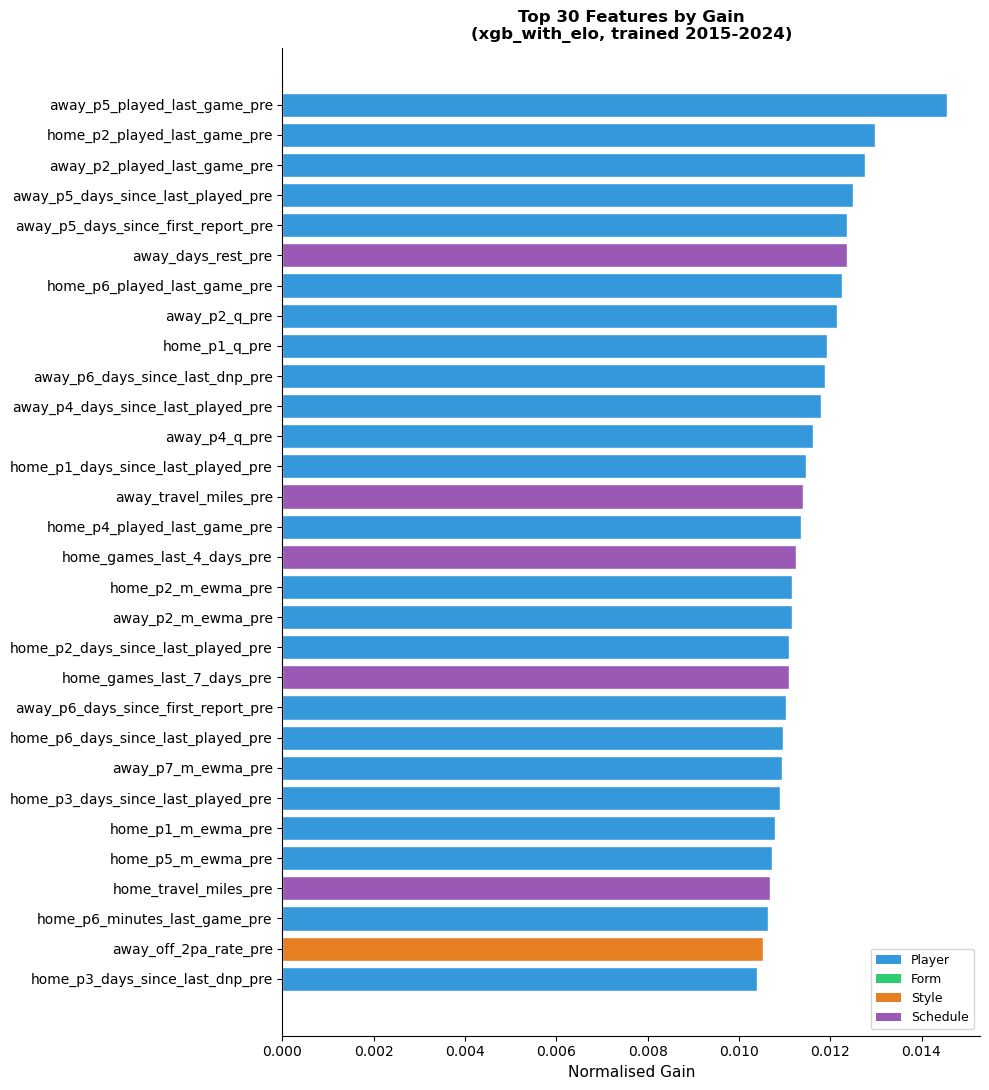

In [43]:
top_n = 30
top = fi_df.head(top_n).sort_values('gain_norm')

# Colour bars by feature block
def feature_block(name):
    if '_m_ewma_' in name or '_q_pre' in name or any(
            f'_p{k}_' in name for k in range(1, N_PLAYERS + 1)):
        return 'player'
    if any(f in name for f in ['net_rtg', 'efg_', 'tov_pct', 'orb_pct', 'ftr_']):
        return 'form'
    if any(f in name for f in ['3pa_rate', '3pa_allowed', '2pa_rate', '2pa_allowed',
                               'off_tov_pct', 'forced_tov']):
        return 'style'
    if any(f in name for f in ['days_rest', 'is_b2b', 'games_last', 'travel', 'timezone']):
        return 'schedule'
    return 'other'

BLOCK_COLORS = {'player': '#3498db', 'form': '#2ecc71', 'style': '#e67e22',
                'schedule': '#9b59b6', 'other': '#95a5a6'}

bar_colors = [BLOCK_COLORS[feature_block(f)] for f in top['feature']]

fig, ax = plt.subplots(figsize=(10, 11))
bars = ax.barh(top['feature'], top['gain_norm'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Normalised Gain', fontsize=11)
ax.set_title(f'Top {top_n} Features by Gain\n(xgb_with_elo, trained 2015-2024)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=b.title())
                   for b, c in BLOCK_COLORS.items() if b != 'other'],
          fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'xgb_elo_top30_gain.png', dpi=150, bbox_inches='tight')
plt.show()


### Graph 7 â€” Importance by Feature Block

Gain share by block:
   block  gain_norm  weight_norm  cover_norm
  player     0.7031       0.7108      0.8061
    form     0.1082       0.1345      0.0683
schedule     0.0975       0.0338      0.0529
   style     0.0912       0.1208      0.0726


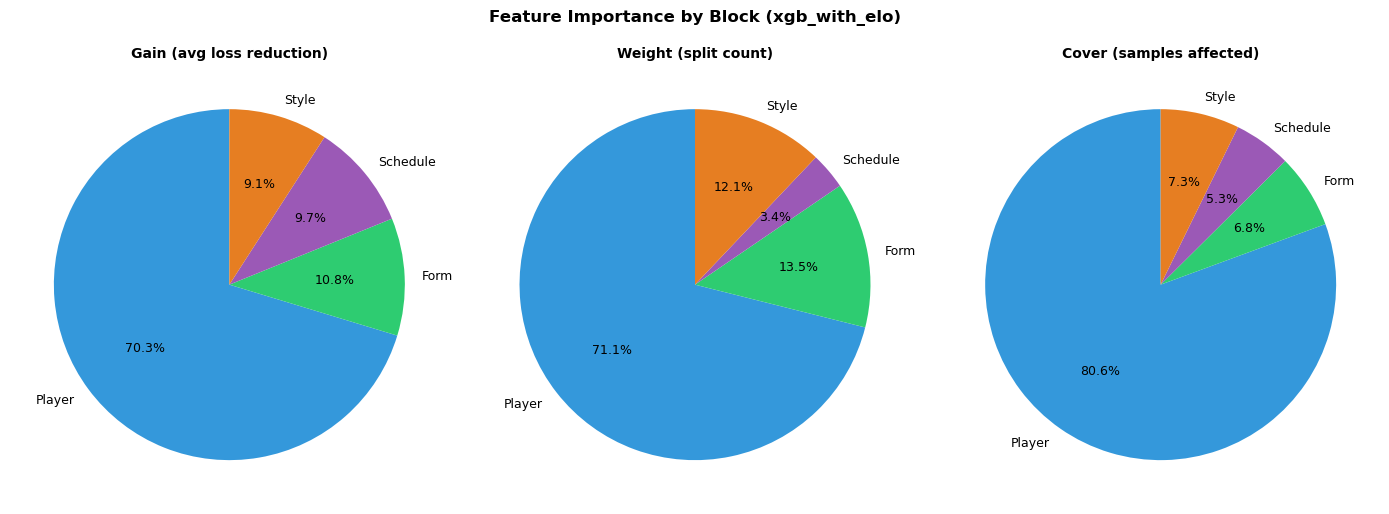

In [44]:
# Aggregate normalised gain by block
fi_df['block'] = fi_df['feature'].apply(feature_block)
block_gain = (
    fi_df.groupby('block')[['gain_norm', 'weight_norm', 'cover_norm']].sum()
    .sort_values('gain_norm', ascending=False)
    .reset_index()
)
print('Gain share by block:')
print(block_gain[['block', 'gain_norm', 'weight_norm', 'cover_norm']].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, title in zip(axes,
    ['gain_norm', 'weight_norm', 'cover_norm'],
    ['Gain (avg loss reduction)', 'Weight (split count)', 'Cover (samples affected)']):
    colors = [BLOCK_COLORS.get(b, '#95a5a6') for b in block_gain['block']]
    wedges, texts, autotexts = ax.pie(
        block_gain[col], labels=block_gain['block'].str.title(),
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9})
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.suptitle('Feature Importance by Block (xgb_with_elo)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'xgb_elo_block_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Graph 8 â€” Gain vs Weight: do important features get used frequently?

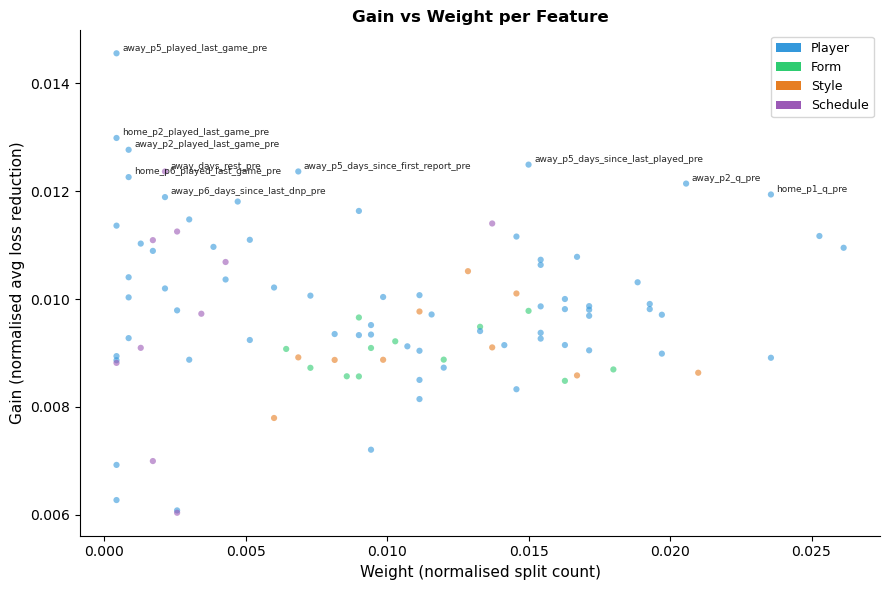

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = [BLOCK_COLORS[feature_block(f)] for f in fi_df['feature']]
ax.scatter(fi_df['weight_norm'], fi_df['gain_norm'], c=colors, alpha=0.6, s=20, edgecolors='none')

# Label the top 10 by gain
for _, row in fi_df.head(10).iterrows():
    ax.annotate(row['feature'], (row['weight_norm'], row['gain_norm']),
                fontsize=6.5, alpha=0.85,
                xytext=(4, 2), textcoords='offset points')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=b.title())
                   for b, c in BLOCK_COLORS.items() if b != 'other'],
          fontsize=9)
ax.set_xlabel('Weight (normalised split count)', fontsize=11)
ax.set_ylabel('Gain (normalised avg loss reduction)', fontsize=11)
ax.set_title('Gain vs Weight per Feature', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'xgb_elo_gain_vs_weight.png', dpi=150, bbox_inches='tight')
plt.show()


### Player Slot Importance: does player rank matter?

Each team has 7 player slots ordered by pre-game strength (p1=best, p7=weakest).
Summing gain across all features within each slot shows whether top players
drive more signal than bench players.

side  slot  gain_sum  n_features
home     1  0.044232           4
home     2  0.051865           5
home     3  0.048859           5
home     4  0.050475           5
home     5  0.057964           6
home     6  0.061664           6
home     7  0.048055           5
away     1  0.042408           5
away     2  0.053850           5
away     3  0.038695           4
away     4  0.040928           4
away     5  0.068307           6
away     6  0.061300           6
away     7  0.034523           4


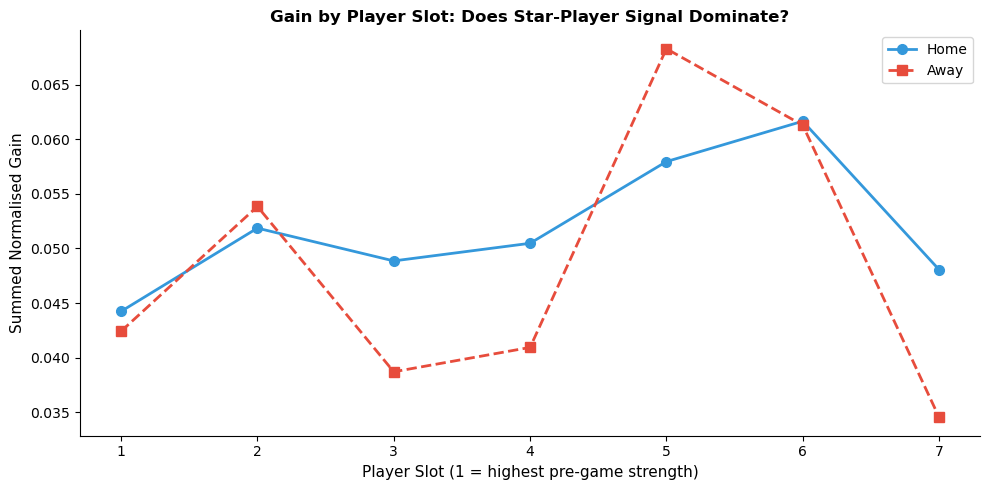

In [46]:
import re

slot_rows = []
for side in ('home', 'away'):
    for slot in range(1, N_PLAYERS + 1):
        prefix = f'{side}_p{slot}_'
        sub = fi_df[fi_df['feature'].str.startswith(prefix)]
        slot_rows.append({
            'side': side, 'slot': slot,
            'gain_sum': sub['gain_norm'].sum(),
            'n_features': len(sub),
        })

slot_df = pd.DataFrame(slot_rows)
print(slot_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = slot_df[slot_df['side'] == 'home']['slot']
ax.plot(x, slot_df[slot_df['side'] == 'home']['gain_sum'],
        '-o', color='#3498db', linewidth=2, markersize=7, label='Home')
ax.plot(x, slot_df[slot_df['side'] == 'away']['gain_sum'],
        '--s', color='#e74c3c', linewidth=2, markersize=7, label='Away')
ax.set_xlabel('Player Slot (1 = highest pre-game strength)', fontsize=11)
ax.set_ylabel('Summed Normalised Gain', fontsize=11)
ax.set_title('Gain by Player Slot: Does Star-Player Signal Dominate?',
             fontsize=12, fontweight='bold')
ax.set_xticks(list(range(1, N_PLAYERS + 1)))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'xgb_elo_slot_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 7B — Feature Importance: xgb_no_elo & Logistic Regression

Compare what the XGBoost model learns **without** the Elo base margin,
and examine logistic regression coefficients to see which features
carry linear signal.

In [47]:
# 7B.1  XGB without Elo: feature importance
imp_types_b = ['gain', 'weight', 'cover']
imp_dfs_b = {}
for imp_type in imp_types_b:
    scores = xgb_no_elo_model.get_score(importance_type=imp_type)
    imp_dfs_b[imp_type] = (
        pd.DataFrame({'feature': list(scores.keys()), imp_type: list(scores.values())})
        .sort_values(imp_type, ascending=False)
        .reset_index(drop=True)
    )

fi_noelo = imp_dfs_b['gain'].merge(imp_dfs_b['weight'], on='feature', how='outer') \
                            .merge(imp_dfs_b['cover'],  on='feature', how='outer') \
                            .fillna(0)
for col in imp_types_b:
    fi_noelo[col + '_norm'] = fi_noelo[col] / fi_noelo[col].sum()

fi_noelo = fi_noelo.sort_values('gain_norm', ascending=False).reset_index(drop=True)
fi_noelo.to_csv(OUT_DIR / 'xgb_no_elo_feature_importance.csv', index=False)
print(f'Features with nonzero importance (xgb_no_elo): {len(fi_noelo)}')
print(fi_noelo[['feature', 'gain_norm', 'weight_norm', 'cover_norm']].head(20).to_string(index=False))

Features with nonzero importance (xgb_no_elo): 114
                            feature  gain_norm  weight_norm  cover_norm
              home_net_rtg_ewma_pre   0.020837     0.026800    0.015017
              away_net_rtg_ewma_pre   0.019513     0.022609    0.011595
                      home_p1_q_pre   0.019107     0.026580    0.013155
                      away_p2_q_pre   0.015755     0.022279    0.010349
                      away_p1_q_pre   0.015179     0.020955    0.009604
 away_p7_days_since_last_played_pre   0.012702     0.003309    0.006128
       away_p5_played_last_game_pre   0.012616     0.000551    0.009716
       away_p2_played_last_game_pre   0.011511     0.000441    0.008131
    home_p5_injury_present_flag_pre   0.011477     0.000331    0.012776
                      home_p2_q_pre   0.010493     0.016874    0.006661
                      away_p3_q_pre   0.010218     0.017867    0.005509
                 home_p4_m_ewma_pre   0.010113     0.023381    0.005851
home_p3_days_

### Graph 9 — Top 30 Features by Gain (xgb_no_elo)

Without the Elo base margin, XGBoost must learn team-strength signal
directly from features. Compare to the with-Elo version to see what
Elo was already capturing.

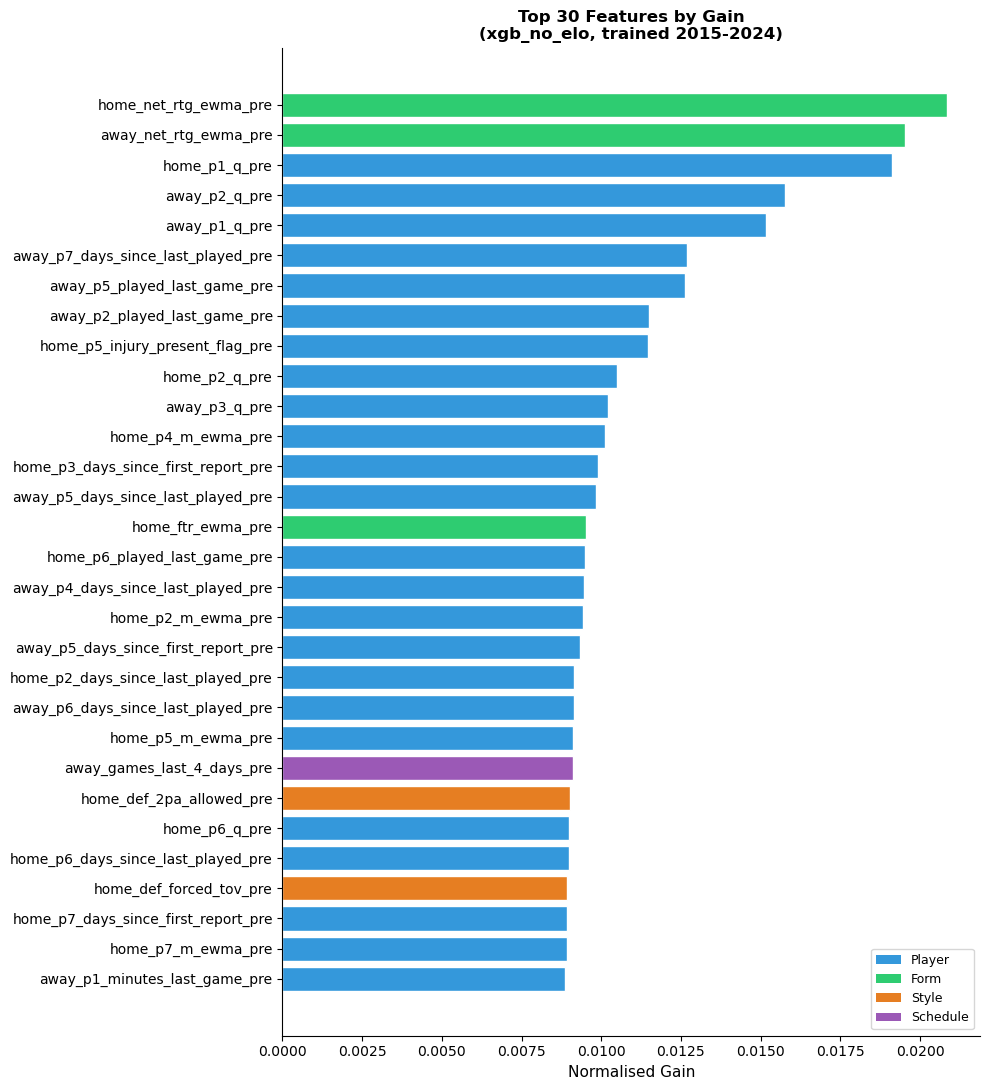

In [48]:
top_ne = 30
top_ne_df = fi_noelo.head(top_ne).sort_values('gain_norm')

bar_colors_ne = [BLOCK_COLORS[feature_block(f)] for f in top_ne_df['feature']]

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(top_ne_df['feature'], top_ne_df['gain_norm'], color=bar_colors_ne, edgecolor='white')
ax.set_xlabel('Normalised Gain', fontsize=11)
ax.set_title(f'Top {top_ne} Features by Gain\n(xgb_no_elo, trained 2015-2024)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=b.title())
                   for b, c in BLOCK_COLORS.items() if b != 'other'],
          fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'xgb_no_elo_top30_gain.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 10 — Block Importance: with-Elo vs without-Elo

Side-by-side comparison of how much gain each feature block contributes
when Elo base margin is present versus absent.

          with_elo  no_elo
block                     
style       0.0912  0.0843
schedule    0.0975  0.0972
form        0.1082  0.1237
player      0.7031  0.6947


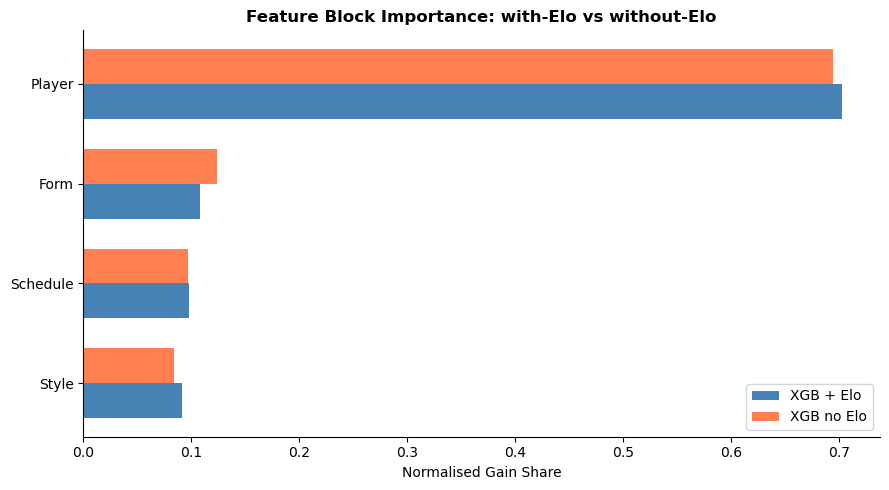

In [49]:
fi_noelo['block'] = fi_noelo['feature'].apply(feature_block)
block_ne = (
    fi_noelo.groupby('block')[['gain_norm']].sum()
    .rename(columns={'gain_norm': 'no_elo'})
)

# fi_df already has 'block' from Section 7
block_elo = (
    fi_df.groupby('block')[['gain_norm']].sum()
    .rename(columns={'gain_norm': 'with_elo'})
)

block_cmp = block_elo.join(block_ne).fillna(0).sort_values('with_elo', ascending=True)
print(block_cmp.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(block_cmp))
w = 0.35
ax.barh([i - w/2 for i in y], block_cmp['with_elo'], w,
        label='XGB + Elo', color='steelblue')
ax.barh([i + w/2 for i in y], block_cmp['no_elo'], w,
        label='XGB no Elo', color='coral')
ax.set_yticks(list(y))
ax.set_yticklabels(block_cmp.index.str.title())
ax.set_xlabel('Normalised Gain Share')
ax.set_title('Feature Block Importance: with-Elo vs without-Elo',
             fontsize=12, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'block_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Logistic Regression Coefficients (logreg_with_elo)

Unlike XGBoost, logistic regression learns a single linear weight per feature.
Coefficients show the direction and magnitude of each feature’s contribution
to log-odds. The first coefficient is the Elo base margin (logit(p_elo)).

In [50]:
# Retrain logreg_with_elo to extract coefficients
lr_elo = LogisticRegression(max_iter=2000, solver='lbfgs', penalty='l2', C=1.0, random_state=42)
X_lr = np.column_stack([bm_full_train, X_full_train])
lr_elo.fit(X_lr, y_full_train)

coef_names = ['base_margin'] + avail
coef_df = pd.DataFrame({
    'feature': coef_names,
    'coefficient': lr_elo.coef_[0],
    'abs_coef': np.abs(lr_elo.coef_[0]),
})
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
coef_df['block'] = coef_df['feature'].apply(lambda f: 'elo' if f == 'base_margin' else feature_block(f))
coef_df.to_csv(OUT_DIR / 'logreg_elo_coefficients.csv', index=False)

print(f'Intercept: {lr_elo.intercept_[0]:.4f}')
print(f'base_margin coefficient: {coef_df[coef_df["feature"]=="base_margin"]["coefficient"].values[0]:.4f}')
print(f'\nTop 25 features by |coefficient|:')
print(coef_df[['feature', 'coefficient', 'block']].head(25).to_string(index=False))

Intercept: 0.0146
base_margin coefficient: 0.9183

Top 25 features by |coefficient|:
                        feature  coefficient    block
                    base_margin     0.918262      elo
                away_is_b2b_pre     0.327702 schedule
   away_p5_played_last_game_pre    -0.303250   player
                  away_p1_q_pre    -0.293324   player
     away_games_last_4_days_pre     0.283633 schedule
                  home_p1_q_pre     0.262626   player
   away_p3_played_last_game_pre    -0.231836   player
   away_p6_played_last_game_pre    -0.225937   player
                  away_p2_q_pre    -0.221236   player
   away_p4_played_last_game_pre    -0.190591   player
   home_p4_played_last_game_pre     0.165841   player
   away_p2_played_last_game_pre     0.163855   player
   home_p7_played_last_game_pre    -0.161614   player
        away_p5_consec_dnps_pre     0.159867   player
        away_p2_consec_dnps_pre    -0.155555   player
home_p5_injury_present_flag_pre    -0.153020   play

### Graph 11 — Top 30 Logistic Regression Coefficients

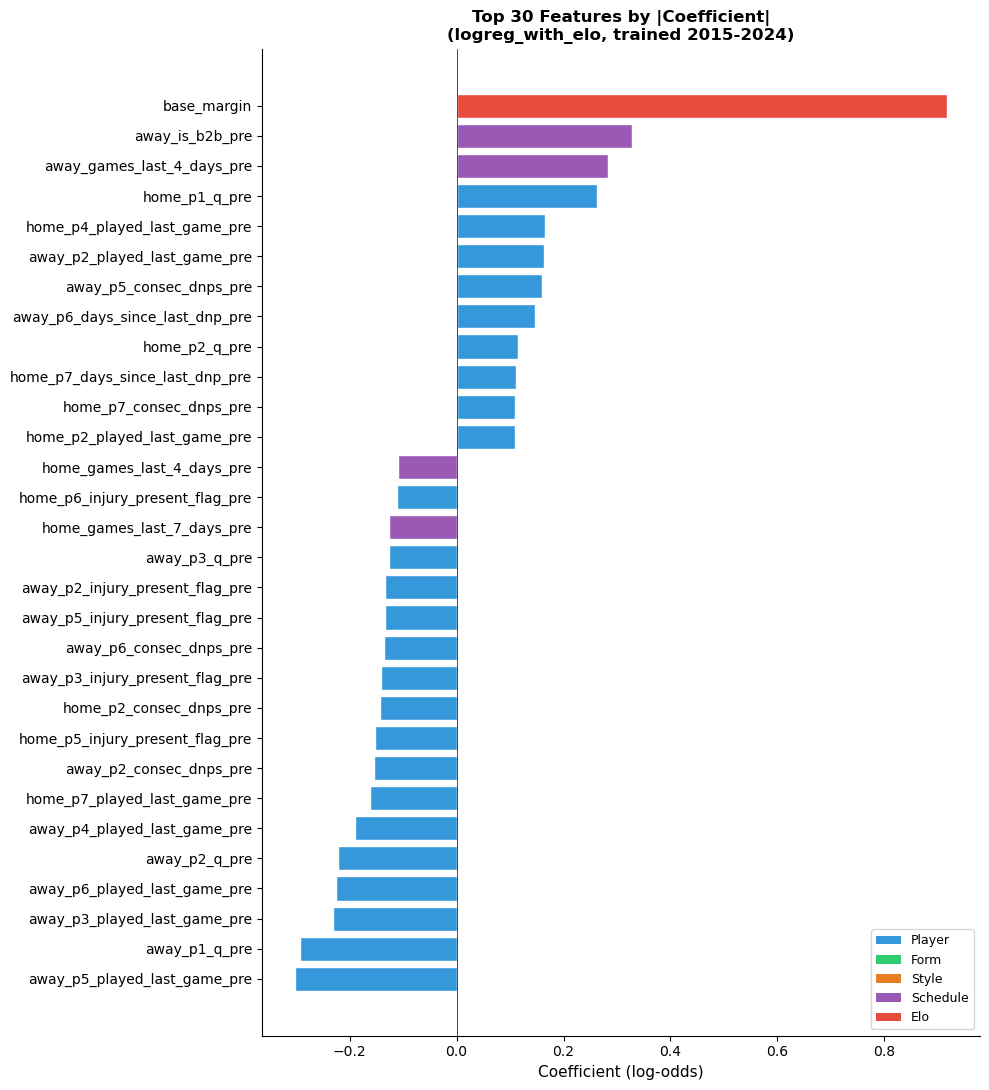

In [51]:
top_lr = coef_df.head(30).sort_values('coefficient')

BLOCK_COLORS_LR = {**BLOCK_COLORS, 'elo': '#e74c3c'}
bar_colors_lr = [BLOCK_COLORS_LR.get(b, '#95a5a6') for b in top_lr['block']]

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(top_lr['feature'], top_lr['coefficient'], color=bar_colors_lr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (log-odds)', fontsize=11)
ax.set_title('Top 30 Features by |Coefficient|\n(logreg_with_elo, trained 2015-2024)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=b.title())
                   for b, c in BLOCK_COLORS_LR.items() if b != 'other'],
          fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'logreg_elo_top30_coef.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# Block-level coefficient magnitude (logreg)
block_lr = (
    coef_df.groupby('block')['abs_coef']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_abs_coef', 'mean': 'mean_abs_coef', 'count': 'n_features'})
    .sort_values('total_abs_coef', ascending=False)
)
print('Logistic regression coefficient magnitude by block:')
print(block_lr.round(4).to_string())

Logistic regression coefficient magnitude by block:
          total_abs_coef  mean_abs_coef  n_features
block                                              
player            7.5640         0.0600         126
schedule          1.2716         0.1060          12
elo               0.9183         0.9183           1
style             0.4384         0.0438          10
form              0.1562         0.0130          12


---
## 8. Model vs Market Odds Comparison

Compare model predictions against pre-tipoff market odds from Kalshi and Polymarket.
Explore whether model–market disagreement contains actionable signal.

In [55]:
# ── Load market data and extract pre-tipoff implied probabilities ──
import numpy as np
from sklearn.metrics import log_loss

# --- Kalshi pre-tipoff odds (aligned to P(home_win)) ---
kalshi_matched = pd.read_csv(PROJECT_ROOT / 'data/kalshi/wnba_2025_game_markets_matched.csv')
kalshi_markets = pd.read_csv(PROJECT_ROOT / 'data/kalshi/kalshi_markets.csv')
kalshi_candles = pd.read_csv(PROJECT_ROOT / 'data/kalshi/kalshi_candles_1m.csv')

# Map market_ticker -> yes_sub_title (the team the YES side represents)
mkt_team = dict(zip(kalshi_markets['market_ticker'], kalshi_markets['yes_sub_title']))

# Extract event_ticker from market_ticker (drop last segment)
kalshi_candles['event_ticker'] = kalshi_candles['market_ticker'].str.rsplit('-', n=1).str[0]

# Parse candle timestamp
kalshi_candles['ts'] = pd.to_datetime(kalshi_candles['end_period_ts'], utc=True)

# Build cutoff: game_date at 23:00 UTC (conservative: most WNBA games tip off 7pm ET = 23:00 UTC or later)
kalshi_matched['cutoff'] = pd.to_datetime(kalshi_matched['game_date']) + pd.Timedelta(hours=23)
kalshi_matched['cutoff'] = kalshi_matched['cutoff'].dt.tz_localize('UTC')

# For each event, get the last candle before cutoff
cutoff_map = dict(zip(kalshi_matched['event_ticker'], kalshi_matched['cutoff']))
kalshi_candles['cutoff'] = kalshi_candles['event_ticker'].map(cutoff_map)
pre = kalshi_candles[kalshi_candles['ts'] <= kalshi_candles['cutoff']].copy()
pre['mid_price'] = (pre['yes_bid_close'] + pre['yes_ask_close']) / 2
last_candle = pre.sort_values('ts').groupby('event_ticker').tail(1)

# Map which team the candle's YES side represents
last_candle['mkt_team'] = last_candle['market_ticker'].map(mkt_team)

# Merge with matched to get game_id and team_b (=home team)
kalshi_odds = last_candle[['event_ticker', 'mid_price', 'mkt_team']].merge(
    kalshi_matched[['event_ticker', 'game_id', 'team_a', 'team_b']], on='event_ticker'
)

# team_b = home team. Convert mid_price to P(home_win).
# If mkt_team == team_b (home), mid_price IS P(home_win)
# If mkt_team == team_a (away), P(home_win) = 1 - mid_price
kalshi_odds['kalshi_prob'] = np.where(
    kalshi_odds['mkt_team'] == kalshi_odds['team_b'],
    kalshi_odds['mid_price'],
    1 - kalshi_odds['mid_price']
)
kalshi_odds = kalshi_odds[['game_id', 'kalshi_prob']].copy()
print(f'Kalshi pre-tipoff odds: {len(kalshi_odds)} games')

# --- Polymarket pre-tipoff odds (aligned to P(home_win)) ---
poly_matched = pd.read_csv(PROJECT_ROOT / 'data/polymarket/wnba_2025_game_markets_matched.csv')
poly_markets = pd.read_csv(PROJECT_ROOT / 'data/polymarket/polymarket_markets.csv')
poly_prices  = pd.read_csv(PROJECT_ROOT / 'data/polymarket/polymarket_prices_history.csv')

# Get game_start_ts from polymarket_markets
gst = dict(zip(poly_markets['condition_id'], poly_markets['game_start_ts']))
poly_matched['game_start_ts'] = poly_matched['condition_id'].map(gst)
poly_matched['game_start_ts'] = pd.to_datetime(poly_matched['game_start_ts'], utc=True)

# Filter prices to team_a tokens only (team_a = away team)
team_a_tokens = set(poly_matched['team_a_token_id'].astype(str))
poly_prices['ts'] = pd.to_datetime(poly_prices['ts'], utc=True)
poly_prices_a = poly_prices[poly_prices['token_id'].astype(str).isin(team_a_tokens)].copy()

# Map token_id -> condition_id -> game_start_ts
tok_to_cid = dict(zip(poly_matched['team_a_token_id'].astype(str), poly_matched['condition_id']))
poly_prices_a['condition_id'] = poly_prices_a['token_id'].astype(str).map(tok_to_cid)
cid_to_gst = dict(zip(poly_matched['condition_id'], poly_matched['game_start_ts']))
poly_prices_a['game_start_ts'] = poly_prices_a['condition_id'].map(cid_to_gst)

# Last price before game start
pre_poly = poly_prices_a[poly_prices_a['ts'] <= poly_prices_a['game_start_ts']].copy()
last_price = pre_poly.sort_values('ts').groupby('condition_id').tail(1)

# Merge with matched for game_id. Price is P(team_a wins) = P(away wins)
poly_odds = last_price[['condition_id', 'price']].merge(
    poly_matched[['condition_id', 'game_id']], on='condition_id'
)
poly_odds['poly_prob'] = 1 - poly_odds['price']  # P(home_win) = 1 - P(away_win)
poly_odds = poly_odds[['game_id', 'poly_prob']].copy()
print(f'Polymarket pre-tipoff odds: {len(poly_odds)} games')

Kalshi pre-tipoff odds: 298 games
Polymarket pre-tipoff odds: 283 games


In [58]:
# ── Build unified comparison table ──
# Get model predictions (xgb_with_elo as the primary model)
holdout_comp = pd.read_csv(PROJECT_ROOT / 'data/model_comparison/holdout_model_comparison_2025.csv')
model_preds = holdout_comp[holdout_comp['model'] == 'xgb_with_elo'][['game_id', 'home_win', 'pred_prob']].copy()
model_preds.rename(columns={'pred_prob': 'model_prob'}, inplace=True)

# Also get Elo-only predictions for comparison
elo_preds = holdout_comp[holdout_comp['model'] == 'elo'][['game_id', 'pred_prob']].copy()
elo_preds.rename(columns={'pred_prob': 'elo_prob'}, inplace=True)

# Merge all sources
comp = model_preds.merge(elo_preds, on='game_id')
comp = comp.merge(kalshi_odds, on='game_id', how='left')
comp = comp.merge(poly_odds, on='game_id', how='left')

n_all = len(comp)
n_kalshi = comp['kalshi_prob'].notna().sum()
n_poly   = comp['poly_prob'].notna().sum()
n_both   = (comp['kalshi_prob'].notna() & comp['poly_prob'].notna()).sum()

print(f'Total holdout games: {n_all}')
print(f'  with Kalshi odds:     {n_kalshi}')
print(f'  with Polymarket odds: {n_poly}')
print(f'  with both:            {n_both}')
print()
print(comp[['game_id', 'home_win', 'model_prob', 'elo_prob', 'kalshi_prob', 'poly_prob']].head(10).to_string(index=False))

Total holdout games: 366
  with Kalshi odds:     349
  with Polymarket odds: 277
  with both:            263

                             game_id  home_win  model_prob  elo_prob  kalshi_prob  poly_prob
127815af-ec83-4409-b0c3-4140a357a60c         1    0.379706  0.554212          NaN      0.330
127815af-ec83-4409-b0c3-4140a357a60c         1    0.379706  0.554212          NaN      0.265
7bbb5b8b-7d33-4ca4-9478-a4732d10c367         0    0.277560  0.320145          NaN        NaN
293a4a3d-3699-4cd3-b085-0dc0e8c56188         0    0.605928  0.661726          NaN      0.310
8e354cb1-e600-4ccd-aec8-3b9daa7dd2ca         1    0.628584  0.582697          NaN      0.610
edfb1305-dc50-48e3-9ea5-c3e16ace9489         1    0.673959  0.633349          NaN      0.765
d307de7c-b2bc-42a3-b338-4205f3918f7c         1    0.342684  0.415337          NaN      0.295
37b8b67b-ceb5-4918-aa27-3d495a19e646         0    0.529319  0.630668          NaN      0.410
b47a1788-78ca-4559-b220-121d3fa3ac55         0    0.3

In [59]:
# ── Headline metrics: log loss, Brier score, accuracy ──
from sklearn.metrics import brier_score_loss

def eval_metrics(y_true, y_prob, label):
    mask = y_prob.notna()
    y, p = y_true[mask].values, y_prob[mask].values
    p = np.clip(p, 0.01, 0.99)
    ll = log_loss(y, p)
    bs = brier_score_loss(y, p)
    acc = ((p > 0.5) == y).mean()
    return {'source': label, 'n': int(mask.sum()), 'log_loss': ll, 'brier': bs, 'accuracy': acc}

rows = [
    eval_metrics(comp['home_win'], comp['model_prob'],  'XGB + Elo (model)'),
    eval_metrics(comp['home_win'], comp['elo_prob'],    'Elo only'),
    eval_metrics(comp['home_win'], comp['kalshi_prob'], 'Kalshi pre-tipoff'),
    eval_metrics(comp['home_win'], comp['poly_prob'],   'Polymarket pre-tipoff'),
]

# Also evaluate on the intersection (games with all 4 sources)
mask_all = comp['kalshi_prob'].notna() & comp['poly_prob'].notna()
comp_all = comp[mask_all].copy()

rows_intersect = [
    eval_metrics(comp_all['home_win'], comp_all['model_prob'],  'XGB + Elo (model)'),
    eval_metrics(comp_all['home_win'], comp_all['elo_prob'],    'Elo only'),
    eval_metrics(comp_all['home_win'], comp_all['kalshi_prob'], 'Kalshi pre-tipoff'),
    eval_metrics(comp_all['home_win'], comp_all['poly_prob'],   'Polymarket pre-tipoff'),
]

print('=== All available games per source ===')
metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

print(f'\n=== Common games only (n={len(comp_all)}) ===')
metrics_intersect = pd.DataFrame(rows_intersect)
print(metrics_intersect.to_string(index=False))

=== All available games per source ===
               source   n  log_loss    brier  accuracy
    XGB + Elo (model) 366  0.615922 0.212256  0.680328
             Elo only 366  0.618830 0.214462  0.672131
    Kalshi pre-tipoff 349  0.611546 0.212756  0.630372
Polymarket pre-tipoff 277  0.673502 0.237251  0.624549

=== Common games only (n=263) ===
               source   n  log_loss    brier  accuracy
    XGB + Elo (model) 263  0.625329 0.215543  0.688213
             Elo only 263  0.629123 0.218882  0.673004
    Kalshi pre-tipoff 263  0.617375 0.215114  0.631179
Polymarket pre-tipoff 263  0.673826 0.237112  0.623574


### 8.1 Directional Disagreement Analysis

When the model and market disagree on which team is the favorite (model says >50% but market says <50% or vice versa), who is more accurate?

In [60]:
# ── Directional disagreement: model vs Kalshi ──
ck = comp.dropna(subset=['kalshi_prob']).copy()

# Directional calls
ck['model_pick_home'] = ck['model_prob'] > 0.5
ck['kalshi_pick_home'] = ck['kalshi_prob'] > 0.5
ck['actual_home_win'] = ck['home_win'] == 1
ck['disagree'] = ck['model_pick_home'] != ck['kalshi_pick_home']

n_agree    = (~ck['disagree']).sum()
n_disagree = ck['disagree'].sum()

print(f'Model vs Kalshi  (n={len(ck)})')
print(f'  Agree on direction:    {n_agree} ({n_agree/len(ck)*100:.1f}%)')
print(f'  Disagree on direction: {n_disagree} ({n_disagree/len(ck)*100:.1f}%)')

if n_disagree > 0:
    dis = ck[ck['disagree']]
    model_right = (dis['model_pick_home'] == dis['actual_home_win']).mean()
    kalshi_right = (dis['kalshi_pick_home'] == dis['actual_home_win']).mean()
    print(f'\n  When they disagree:')
    print(f'    Model correct:  {model_right:.1%}')
    print(f'    Kalshi correct: {kalshi_right:.1%}')
    print(f'    (These sum to ~100% since one must be right when they disagree)')

if n_agree > 0:
    agr = ck[~ck['disagree']]
    print(f'\n  When they agree:')
    agree_acc = (agr['model_pick_home'] == agr['actual_home_win']).mean()
    print(f'    Joint accuracy: {agree_acc:.1%}')

# Same for Polymarket
cp = comp.dropna(subset=['poly_prob']).copy()
cp['model_pick_home'] = cp['model_prob'] > 0.5
cp['poly_pick_home'] = cp['poly_prob'] > 0.5
cp['actual_home_win'] = cp['home_win'] == 1
cp['disagree'] = cp['model_pick_home'] != cp['poly_pick_home']

n_agree_p    = (~cp['disagree']).sum()
n_disagree_p = cp['disagree'].sum()

print(f'\nModel vs Polymarket  (n={len(cp)})')
print(f'  Agree on direction:    {n_agree_p} ({n_agree_p/len(cp)*100:.1f}%)')
print(f'  Disagree on direction: {n_disagree_p} ({n_disagree_p/len(cp)*100:.1f}%)')

if n_disagree_p > 0:
    dis_p = cp[cp['disagree']]
    model_right_p = (dis_p['model_pick_home'] == dis_p['actual_home_win']).mean()
    poly_right_p  = (dis_p['poly_pick_home'] == dis_p['actual_home_win']).mean()
    print(f'\n  When they disagree:')
    print(f'    Model correct:      {model_right_p:.1%}')
    print(f'    Polymarket correct: {poly_right_p:.1%}')

if n_agree_p > 0:
    agr_p = cp[~cp['disagree']]
    agree_acc_p = (agr_p['model_pick_home'] == agr_p['actual_home_win']).mean()
    print(f'\n  When they agree:')
    print(f'    Joint accuracy: {agree_acc_p:.1%}')

Model vs Kalshi  (n=349)
  Agree on direction:    283 (81.1%)
  Disagree on direction: 66 (18.9%)

  When they disagree:
    Model correct:  65.2%
    Kalshi correct: 34.8%
    (These sum to ~100% since one must be right when they disagree)

  When they agree:
    Joint accuracy: 69.6%

Model vs Polymarket  (n=277)
  Agree on direction:    214 (77.3%)
  Disagree on direction: 63 (22.7%)

  When they disagree:
    Model correct:      61.9%
    Polymarket correct: 38.1%

  When they agree:
    Joint accuracy: 69.6%


### 8.2 Disagreement Band Analysis

Bucket games by the absolute difference between model and market probability, then measure accuracy and log loss within each band.

In [65]:
# ── Disagreement bands: model vs Kalshi ──
def disagreement_band_analysis(df, model_col, market_col, market_name, y_col='home_win'):
    d = df.dropna(subset=[market_col]).copy()
    d['diff'] = (d[model_col] - d[market_col]).abs()
    
    bins = [0, 0.05, 0.10, 0.20, 1.0]
    labels = ['0-5%', '5-10%', '10-20%', '20%+']
    d['band'] = pd.cut(d['diff'], bins=bins, labels=labels, right=True)
    
    rows = []
    for band in labels:
        sub = d[d['band'] == band]
        if len(sub) == 0:
            continue
        y = sub[y_col].values
        mp = np.clip(sub[model_col].values, 0.01, 0.99)
        mkt = np.clip(sub[market_col].values, 0.01, 0.99)
        rows.append({
            'band': band,
            'n': len(sub),
            'model_ll': log_loss(y, mp),
            f'{market_name}_ll': log_loss(y, mkt),
            'model_acc': ((mp > 0.5) == y).mean(),
            f'{market_name}_acc': ((mkt > 0.5) == y).mean(),
            'mean_diff': sub['diff'].mean(),
        })
    return pd.DataFrame(rows)

print('=== Model vs Kalshi: disagreement bands ===')
bands_k = disagreement_band_analysis(comp, 'model_prob', 'kalshi_prob', 'kalshi')
print(bands_k.to_string(index=False))

print(f'\n=== Model vs Polymarket: disagreement bands ===')
bands_p = disagreement_band_analysis(comp, 'model_prob', 'poly_prob', 'poly')
print(bands_p.to_string(index=False))

=== Model vs Kalshi: disagreement bands ===
  band   n  model_ll  kalshi_ll  model_acc  kalshi_acc  mean_diff
  0-5% 141  0.541306   0.539236   0.751773    0.716312   0.022493
 5-10%  91  0.600997   0.595048   0.681319    0.681319   0.074987
10-20%  77  0.670766   0.712256   0.688312    0.467532   0.140356
  20%+  40  0.793302   0.710103   0.475000    0.525000   0.273265

=== Model vs Polymarket: disagreement bands ===
  band  n  model_ll  poly_ll  model_acc  poly_acc  mean_diff
  0-5% 91  0.565814 0.569349   0.714286  0.736264   0.024894
 5-10% 60  0.650918 0.618324   0.683333  0.650000   0.072849
10-20% 74  0.659709 0.648657   0.662162  0.581081   0.143326
  20%+ 52  0.666243 0.954794   0.634615  0.461538   0.356484


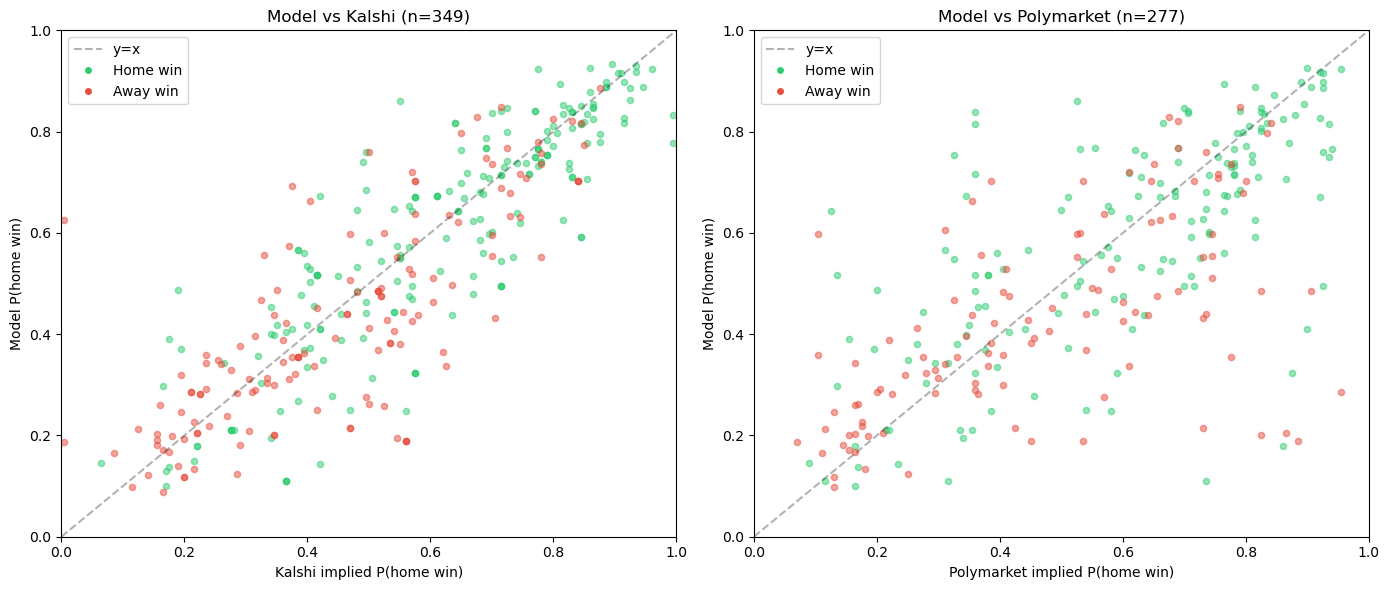

In [63]:
# ── Visualize: model vs market scatter ──
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_scatter(ax, df, market_col, market_name):
    home_w = df[df["home_win"] == 1]
    away_w = df[df["home_win"] == 0]
    ax.scatter(home_w[market_col], home_w["model_prob"], c="#2ecc71", alpha=0.5, s=20)
    ax.scatter(away_w[market_col], away_w["model_prob"], c="#e74c3c", alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel(f"{market_name} implied P(home win)")
    ax.set_ylabel("Model P(home win)")
    ax.set_title(f"Model vs {market_name} (n={len(df)})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(
        handles=[
            Line2D([], [], color="k", ls="--", alpha=0.3, label="y=x"),
            Line2D([], [], marker="o", color="w", markerfacecolor="#2ecc71", markersize=6, label="Home win"),
            Line2D([], [], marker="o", color="w", markerfacecolor="#e74c3c", markersize=6, label="Away win"),
        ],
        loc="upper left",
    )

plot_scatter(axes[0], comp.dropna(subset=["kalshi_prob"]), "kalshi_prob", "Kalshi")
plot_scatter(axes[1], comp.dropna(subset=["poly_prob"]), "poly_prob", "Polymarket")

plt.tight_layout()
plt.show()

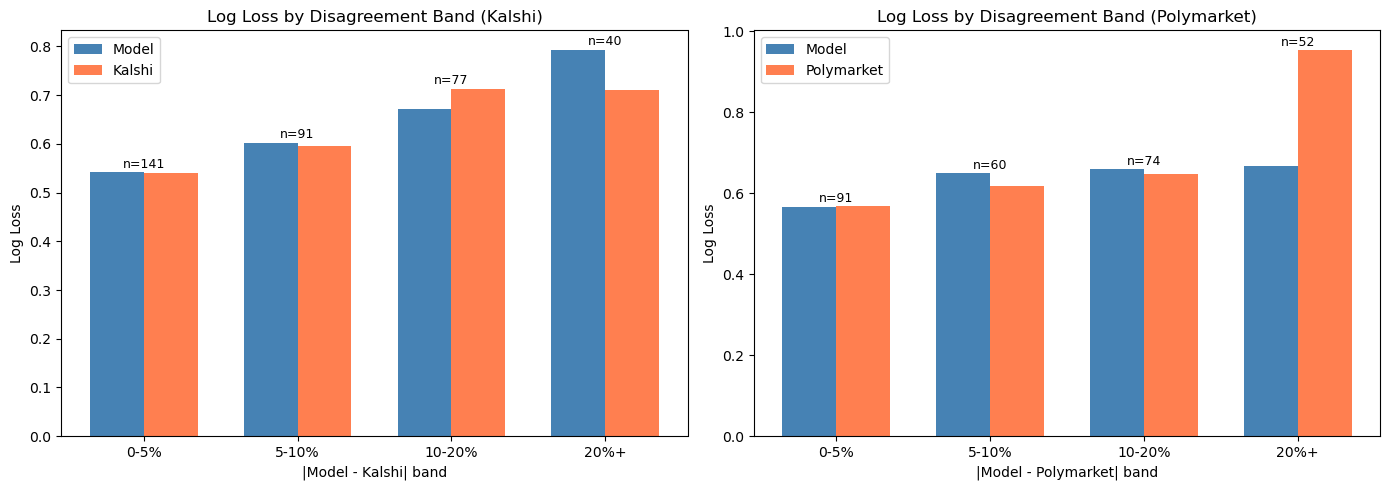

In [66]:
# ── Bar chart: log loss by disagreement band ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kalshi bands
ax = axes[0]
if len(bands_k) > 0:
    x = range(len(bands_k))
    w = 0.35
    ax.bar([i - w/2 for i in x], bands_k['model_ll'], w, label='Model', color='steelblue')
    ax.bar([i + w/2 for i in x], bands_k['kalshi_ll'], w, label='Kalshi', color='coral')
    ax.set_xticks(list(x))
    ax.set_xticklabels(bands_k['band'])
    for i, row in bands_k.iterrows():
        ax.text(i, max(row['model_ll'], row['kalshi_ll']) + 0.01, f'n={row["n"]}',
                ha='center', fontsize=9)
    ax.set_ylabel('Log Loss')
    ax.set_xlabel('|Model - Kalshi| band')
    ax.set_title('Log Loss by Disagreement Band (Kalshi)')
    ax.legend()

# Polymarket bands
ax = axes[1]
if len(bands_p) > 0:
    x = range(len(bands_p))
    ax.bar([i - w/2 for i in x], bands_p['model_ll'], w, label='Model', color='steelblue')
    ax.bar([i + w/2 for i in x], bands_p['poly_ll'], w, label='Polymarket', color='coral')
    ax.set_xticks(list(x))
    ax.set_xticklabels(bands_p['band'])
    for i, row in bands_p.iterrows():
        ax.text(i, max(row['model_ll'], row['poly_ll']) + 0.01, f'n={row["n"]}',
                ha='center', fontsize=9)
    ax.set_ylabel('Log Loss')
    ax.set_xlabel('|Model - Polymarket| band')
    ax.set_title('Log Loss by Disagreement Band (Polymarket)')
    ax.legend()

plt.tight_layout()
plt.show()

### 8.3 Interpretation

Key questions answered:
1. **Does the model beat the market on log loss?** Compare headline metrics above.
2. **Is there directional signal in disagreement?** When model and market disagree on the favorite, who is right more often?
3. **Does larger disagreement = larger edge?** If the model outperforms more in higher-disagreement bands, that suggests a real informational advantage, not noise.

These results inform the trading layer: disagreement bands where the model consistently outperforms the market represent the best entry candidates.